In [1]:
import os
import sys
sys.path.append("../")
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

from utils.datasets import GCDataset, Dataset
from agents.gcivl.state.dual import GCIVLDualAgent, get_config as get_config_dual
from agents.gcivl.original import GCIVLAgent, get_config
from utils.flax_utils import restore_agent
import ogbench

env_medium, train_dataset_medium, val_dataset_medium = ogbench.make_env_and_datasets(
    dataset_name="antmaze-medium-navigate-v0"
)
env_large, train_dataset_large, val_dataset_large = ogbench.make_env_and_datasets(
    dataset_name="antmaze-large-navigate-v0"
)
agent_config = get_config()
agent_config_dual = get_config_dual()

train_dataset_med = GCDataset(Dataset.create(norm=False, **train_dataset_medium), agent_config)
train_dataset_large = GCDataset(Dataset.create(norm=False, **train_dataset_large), agent_config)

example_batch_med = train_dataset_med.sample(1)
example_batch_large = train_dataset_large.sample(1)

agent_gcivl = GCIVLAgent.create(
    0, example_batch_med['observations'], example_batch_med['actions'], agent_config, ex_goals=None
)
agent_gcivl_dual = GCIVLDualAgent.create(
    0, example_batch_med['observations'], example_batch_med['actions'], agent_config_dual, ex_goals=None
)

In [3]:
env_large.unwrapped.task_infos

[{'task_name': 'task1',
  'init_ij': (1, 1),
  'init_xy': (0.0, 0.0),
  'goal_ij': (7, 10),
  'goal_xy': (36.0, 24.0)},
 {'task_name': 'task2',
  'init_ij': (5, 4),
  'init_xy': (12.0, 16.0),
  'goal_ij': (7, 1),
  'goal_xy': (0.0, 24.0)},
 {'task_name': 'task3',
  'init_ij': (7, 4),
  'init_xy': (12.0, 24.0),
  'goal_ij': (1, 10),
  'goal_xy': (36.0, 0.0)},
 {'task_name': 'task4',
  'init_ij': (3, 8),
  'init_xy': (28.0, 8.0),
  'goal_ij': (5, 4),
  'goal_xy': (12.0, 16.0)},
 {'task_name': 'task5',
  'init_ij': (1, 1),
  'init_xy': (0.0, 0.0),
  'goal_ij': (5, 4),
  'goal_xy': (12.0, 16.0)}]

In [4]:
agent_gcivl = restore_agent(
    agent_gcivl,
    "../results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints",
    step=1_000_000
)
agent_gcivl_dual = restore_agent(
    agent_gcivl_dual,
    "../results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints",
    step=1_000_000
)
agent_gcivl_eikonal = restore_agent(
    agent_gcivl,
    "../results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints",
    step=1_000_000
)
agent_gcivl_dual_eikonal = restore_agent(
    agent_gcivl_dual,
    "../results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000_eikonal-dual/checkpoints",
    step=1_000_000
)

Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000_eikonal-dual/checkpoints


In [4]:
from utils.antmaze_contours import plot_antmaze_learned_and_analytic
from IPython.display import Image, display
import os

samples=train_dataset_large.sample(100)['observations']

def plot_agent_contours(agent, maze_type='medium', obs_dim=None, env=None, save_dir='plots'):
    """
    Plots and displays learned vs analytic contours for an AntMaze agent.
    
    Args:
        agent: The pretrained agent (e.g., GCIVLDualAgent).
        maze_type: 'medium' or 'large'.
        obs_dim: Total dimension of the observation (e.g., 29). If None, tries to infer from env or agent.
        env: Optional environment to infer obs_dim from.
        save_dir: Directory to save the resulting plot.
    """
    # 1. Infer obs_dim if not provided
    if obs_dim is None:
        if env is not None:
            obs_dim = env.observation_space.shape[0]
    # 2. Ensure save directory exists
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # 3. Call the plotting utility
    save_path = plot_antmaze_learned_and_analytic(
        agent=agent,
        maze_type=maze_type,
        save_dir=save_dir,
        obs_dim=obs_dim,
        # task_name=f"agent_step_{agent.network.step}",
        goal_xy=(36, 0),
        dataset_samples=samples,
        max_dataset_samples=64
    )

    # 4. Display in notebook
    display(Image(save_path))
    return save_path


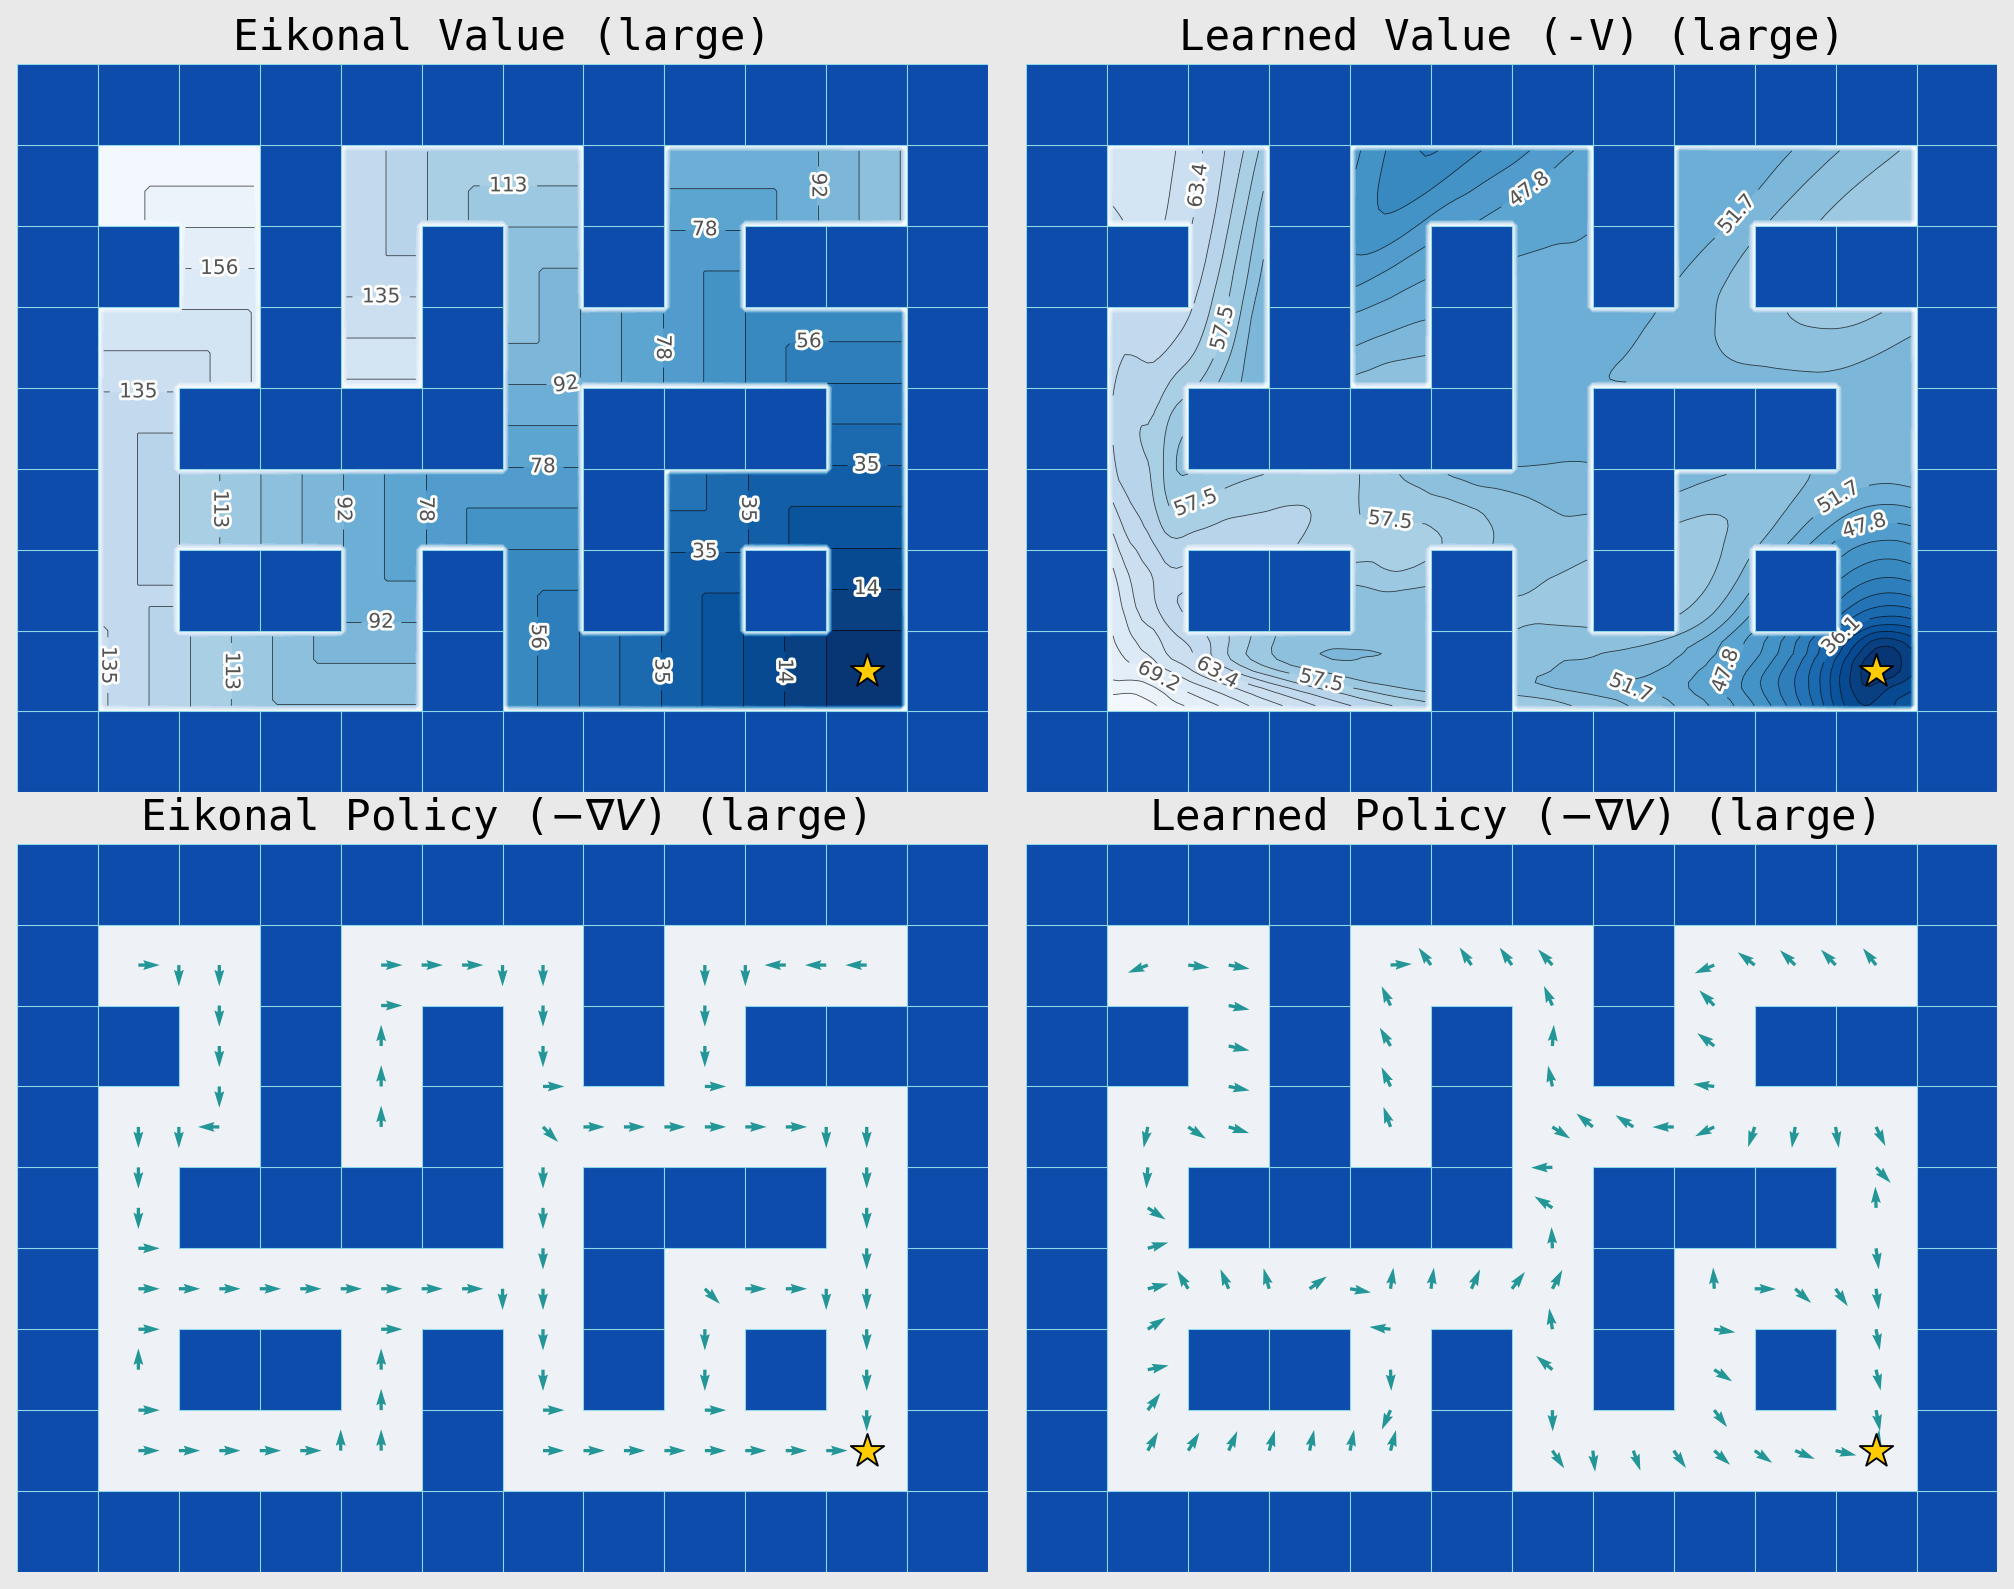

'plots/antmaze_large_learned_analytic_contours.png'

In [5]:
plot_agent_contours(agent_gcivl, maze_type='large', env=env_large)

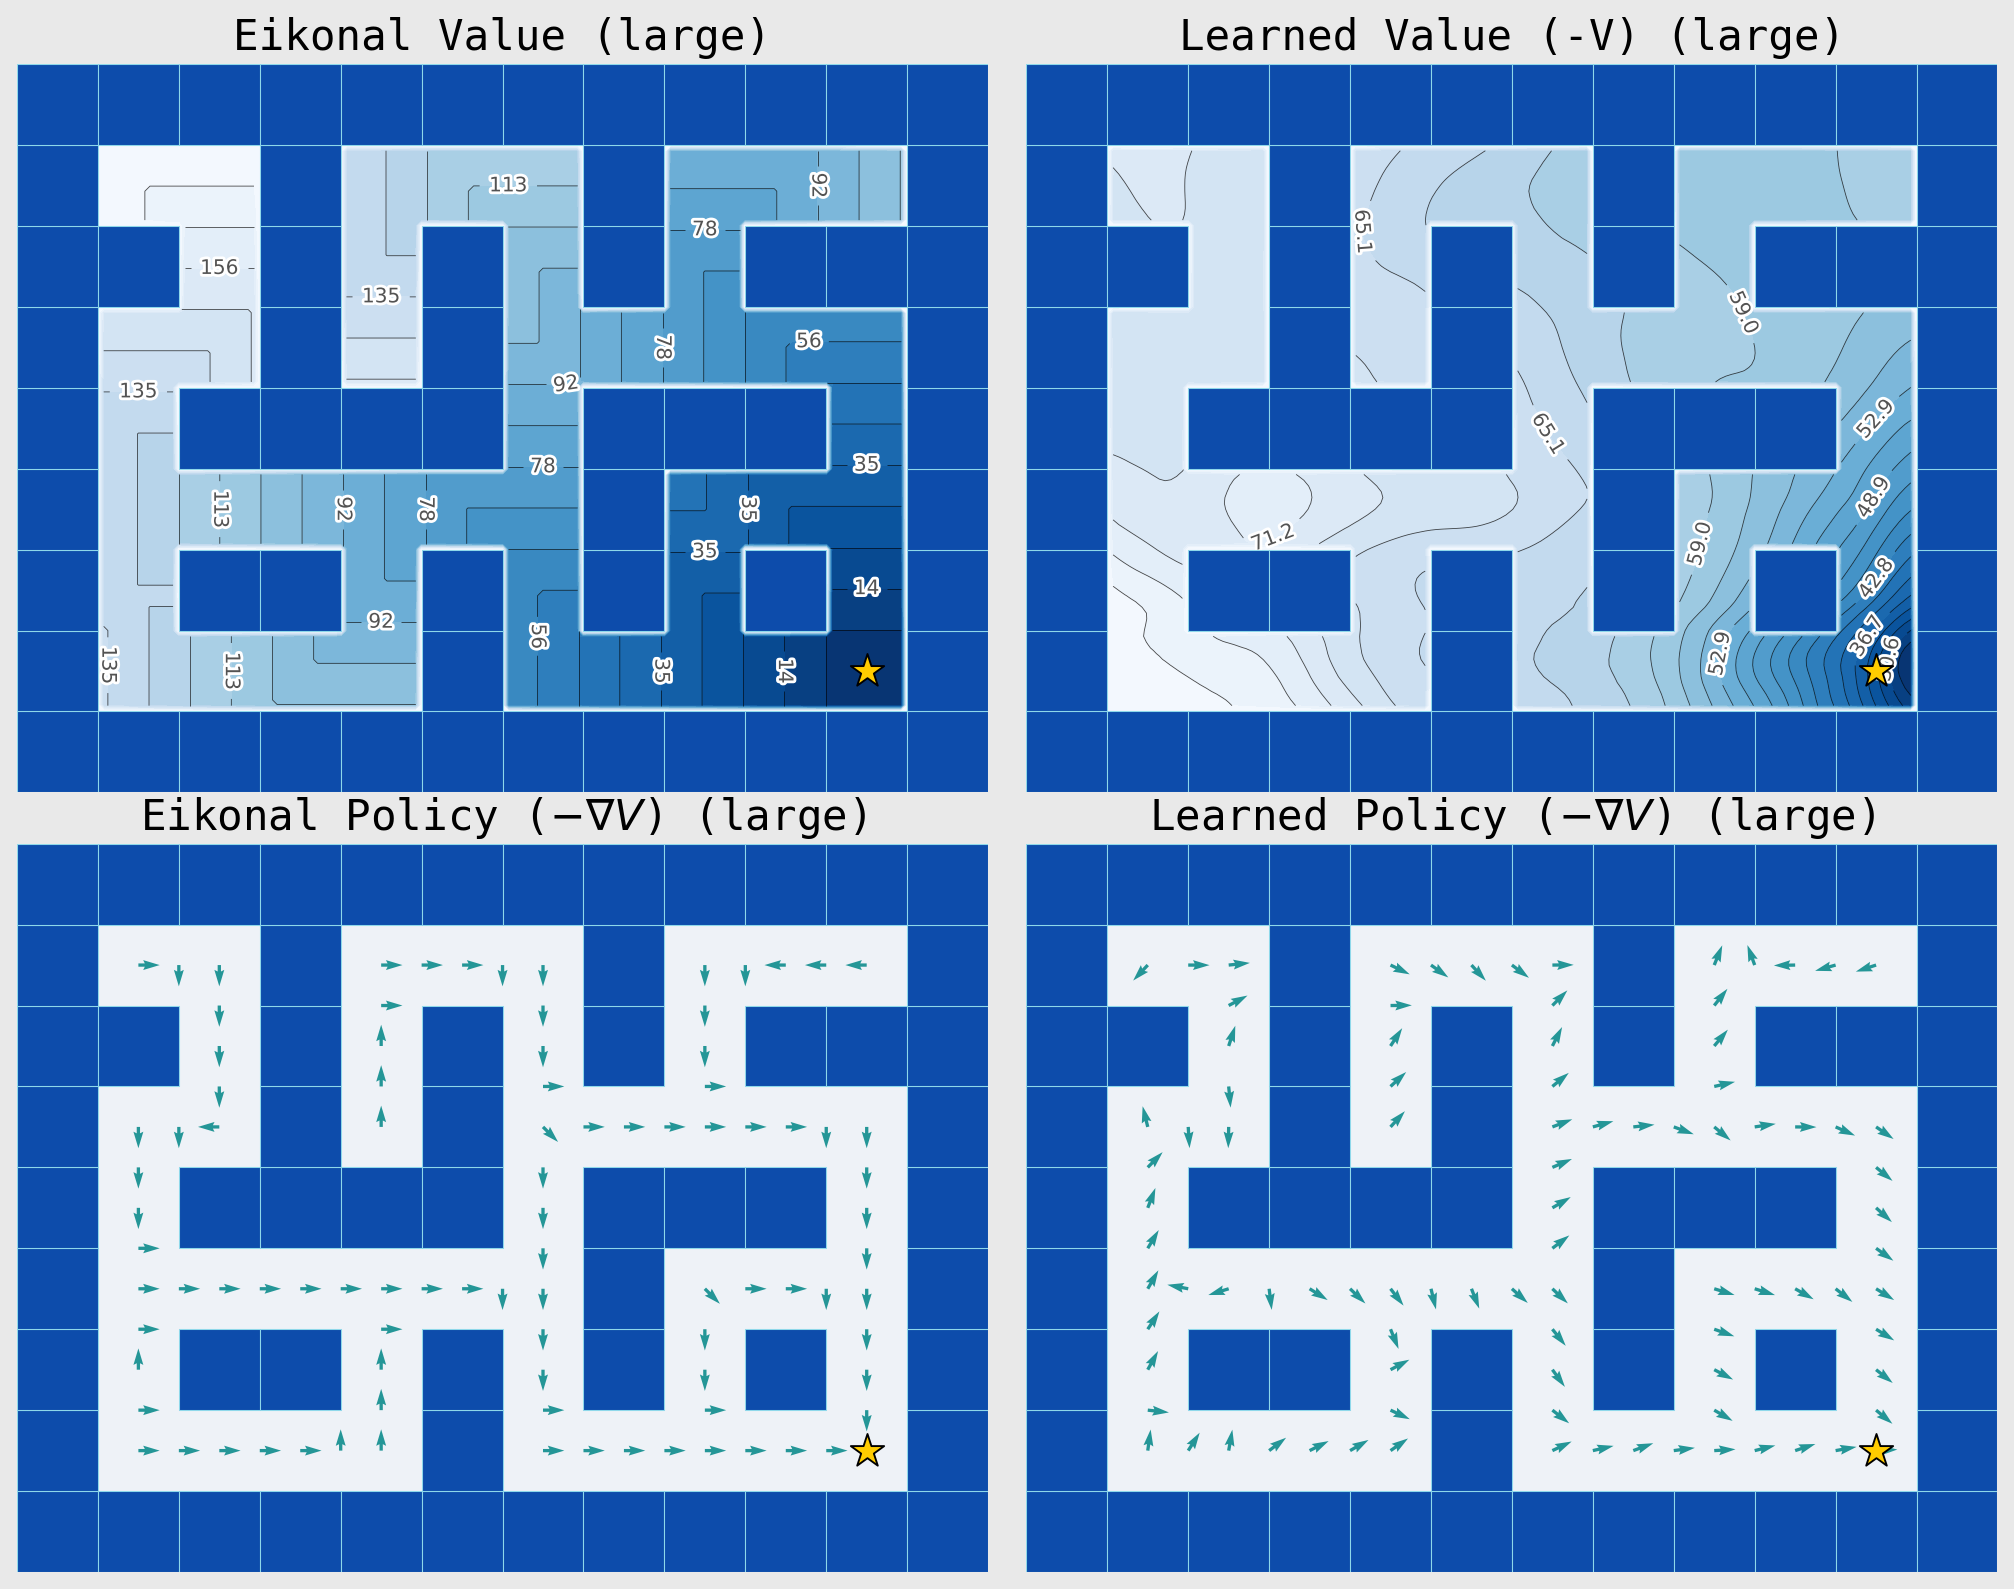

'plots/antmaze_large_learned_analytic_contours.png'

In [6]:
plot_agent_contours(agent_gcivl_dual, maze_type='large', env=env_large)

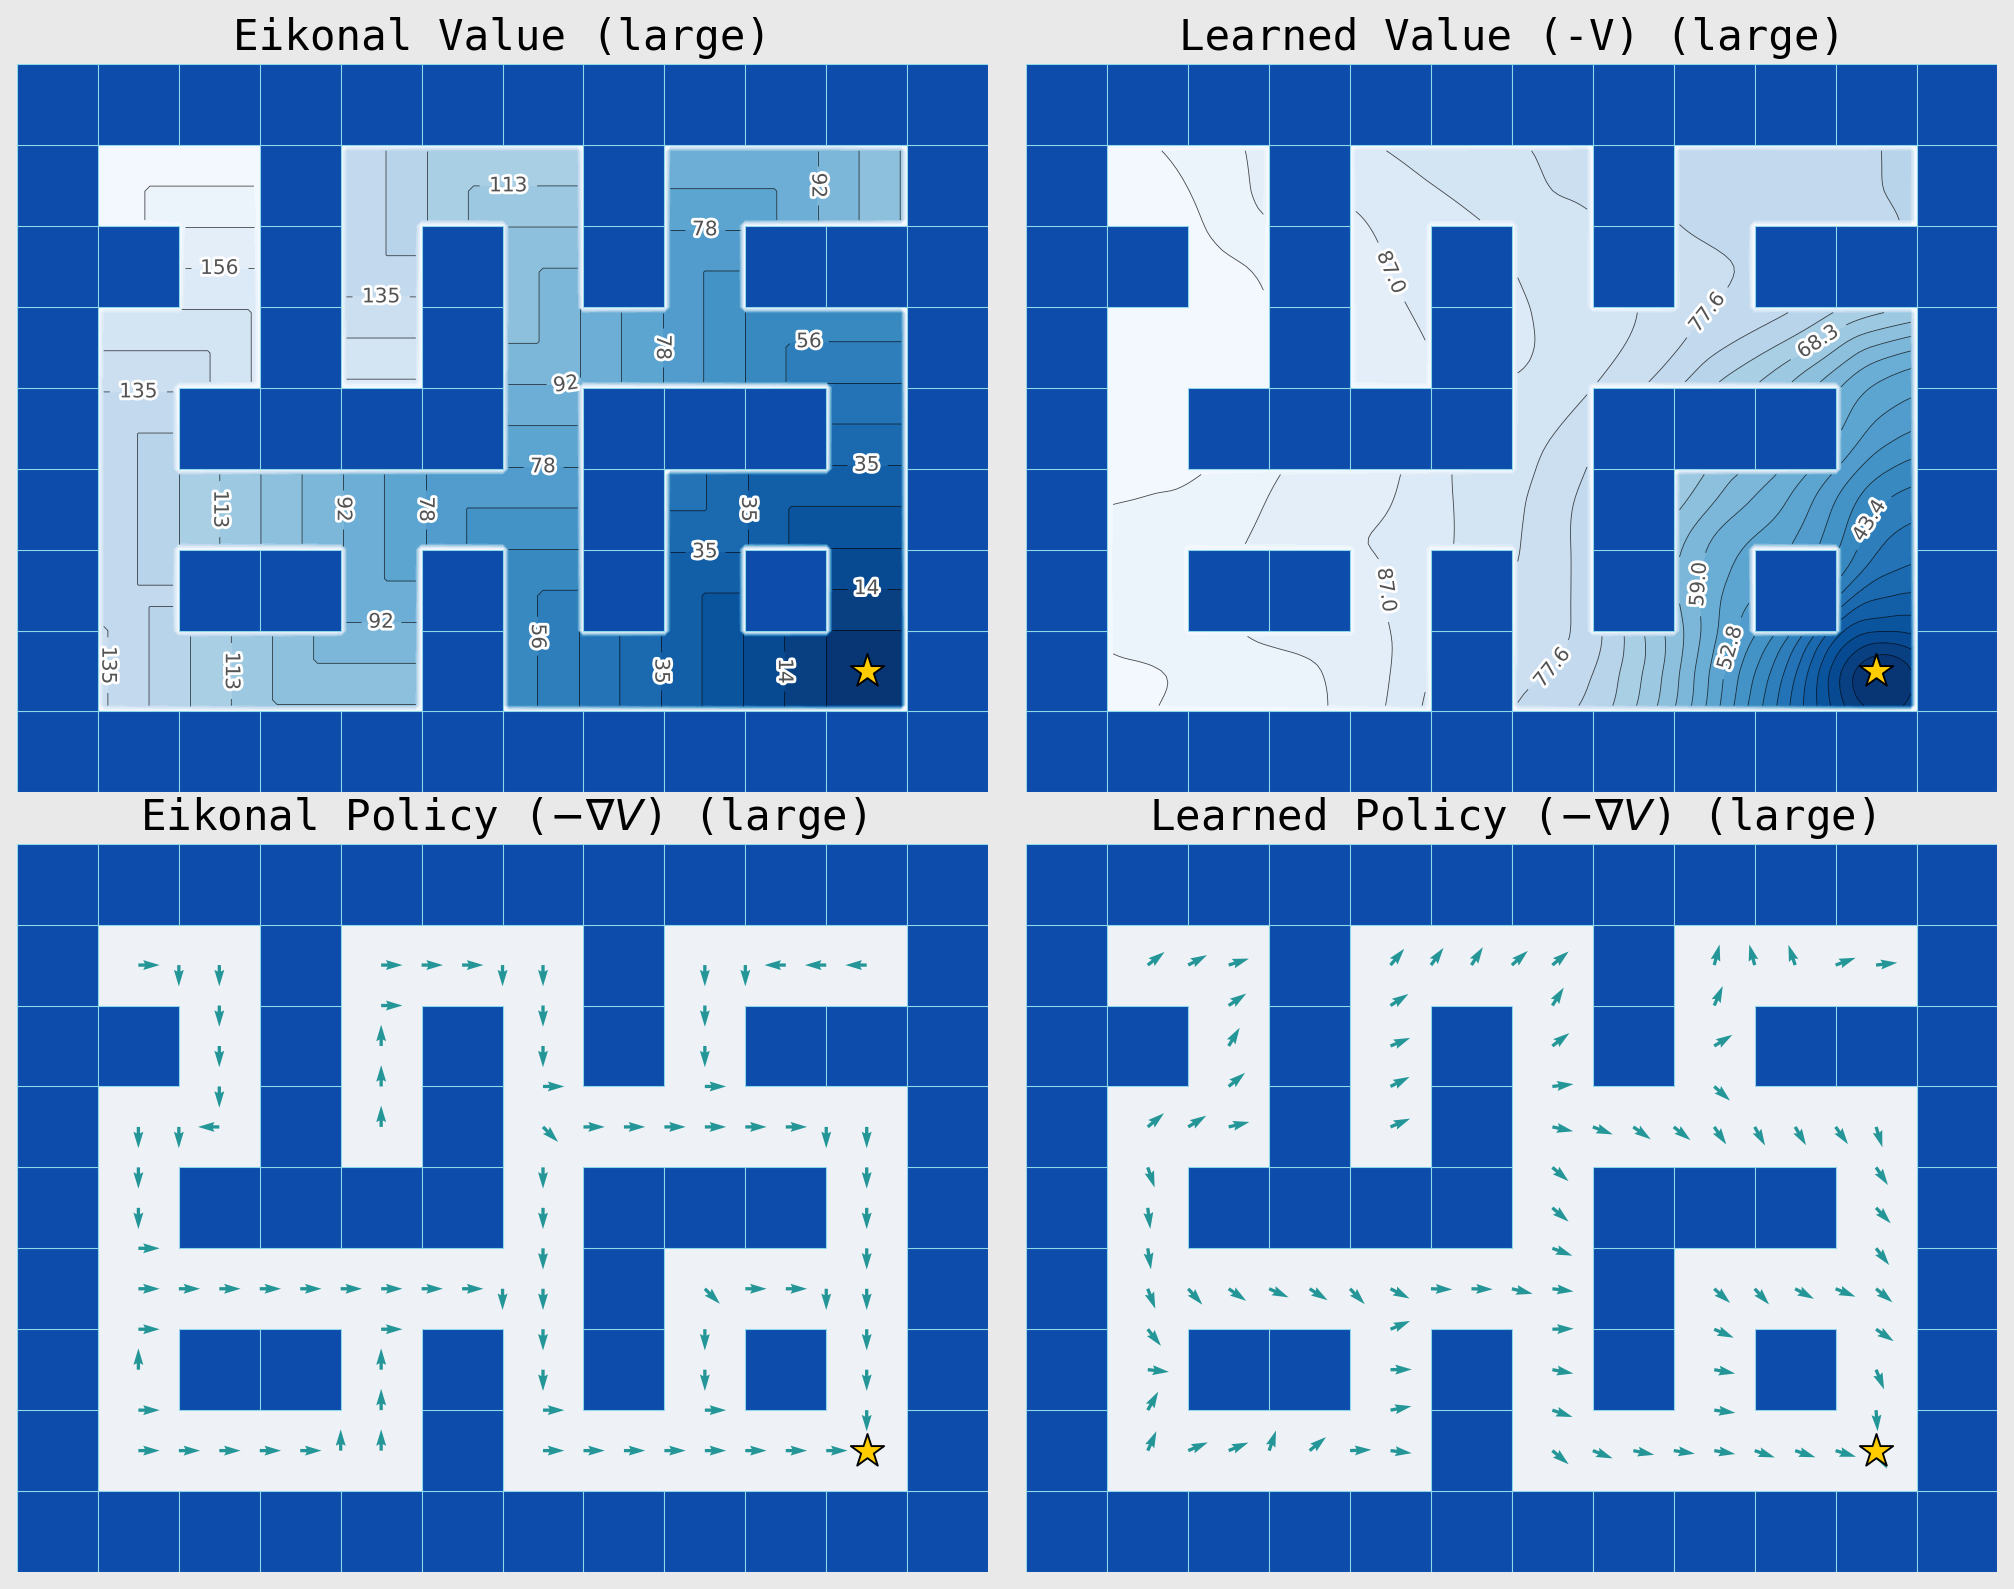

'plots/antmaze_large_learned_analytic_contours.png'

In [7]:
plot_agent_contours(agent_gcivl_eikonal, maze_type='large', env=env_large)

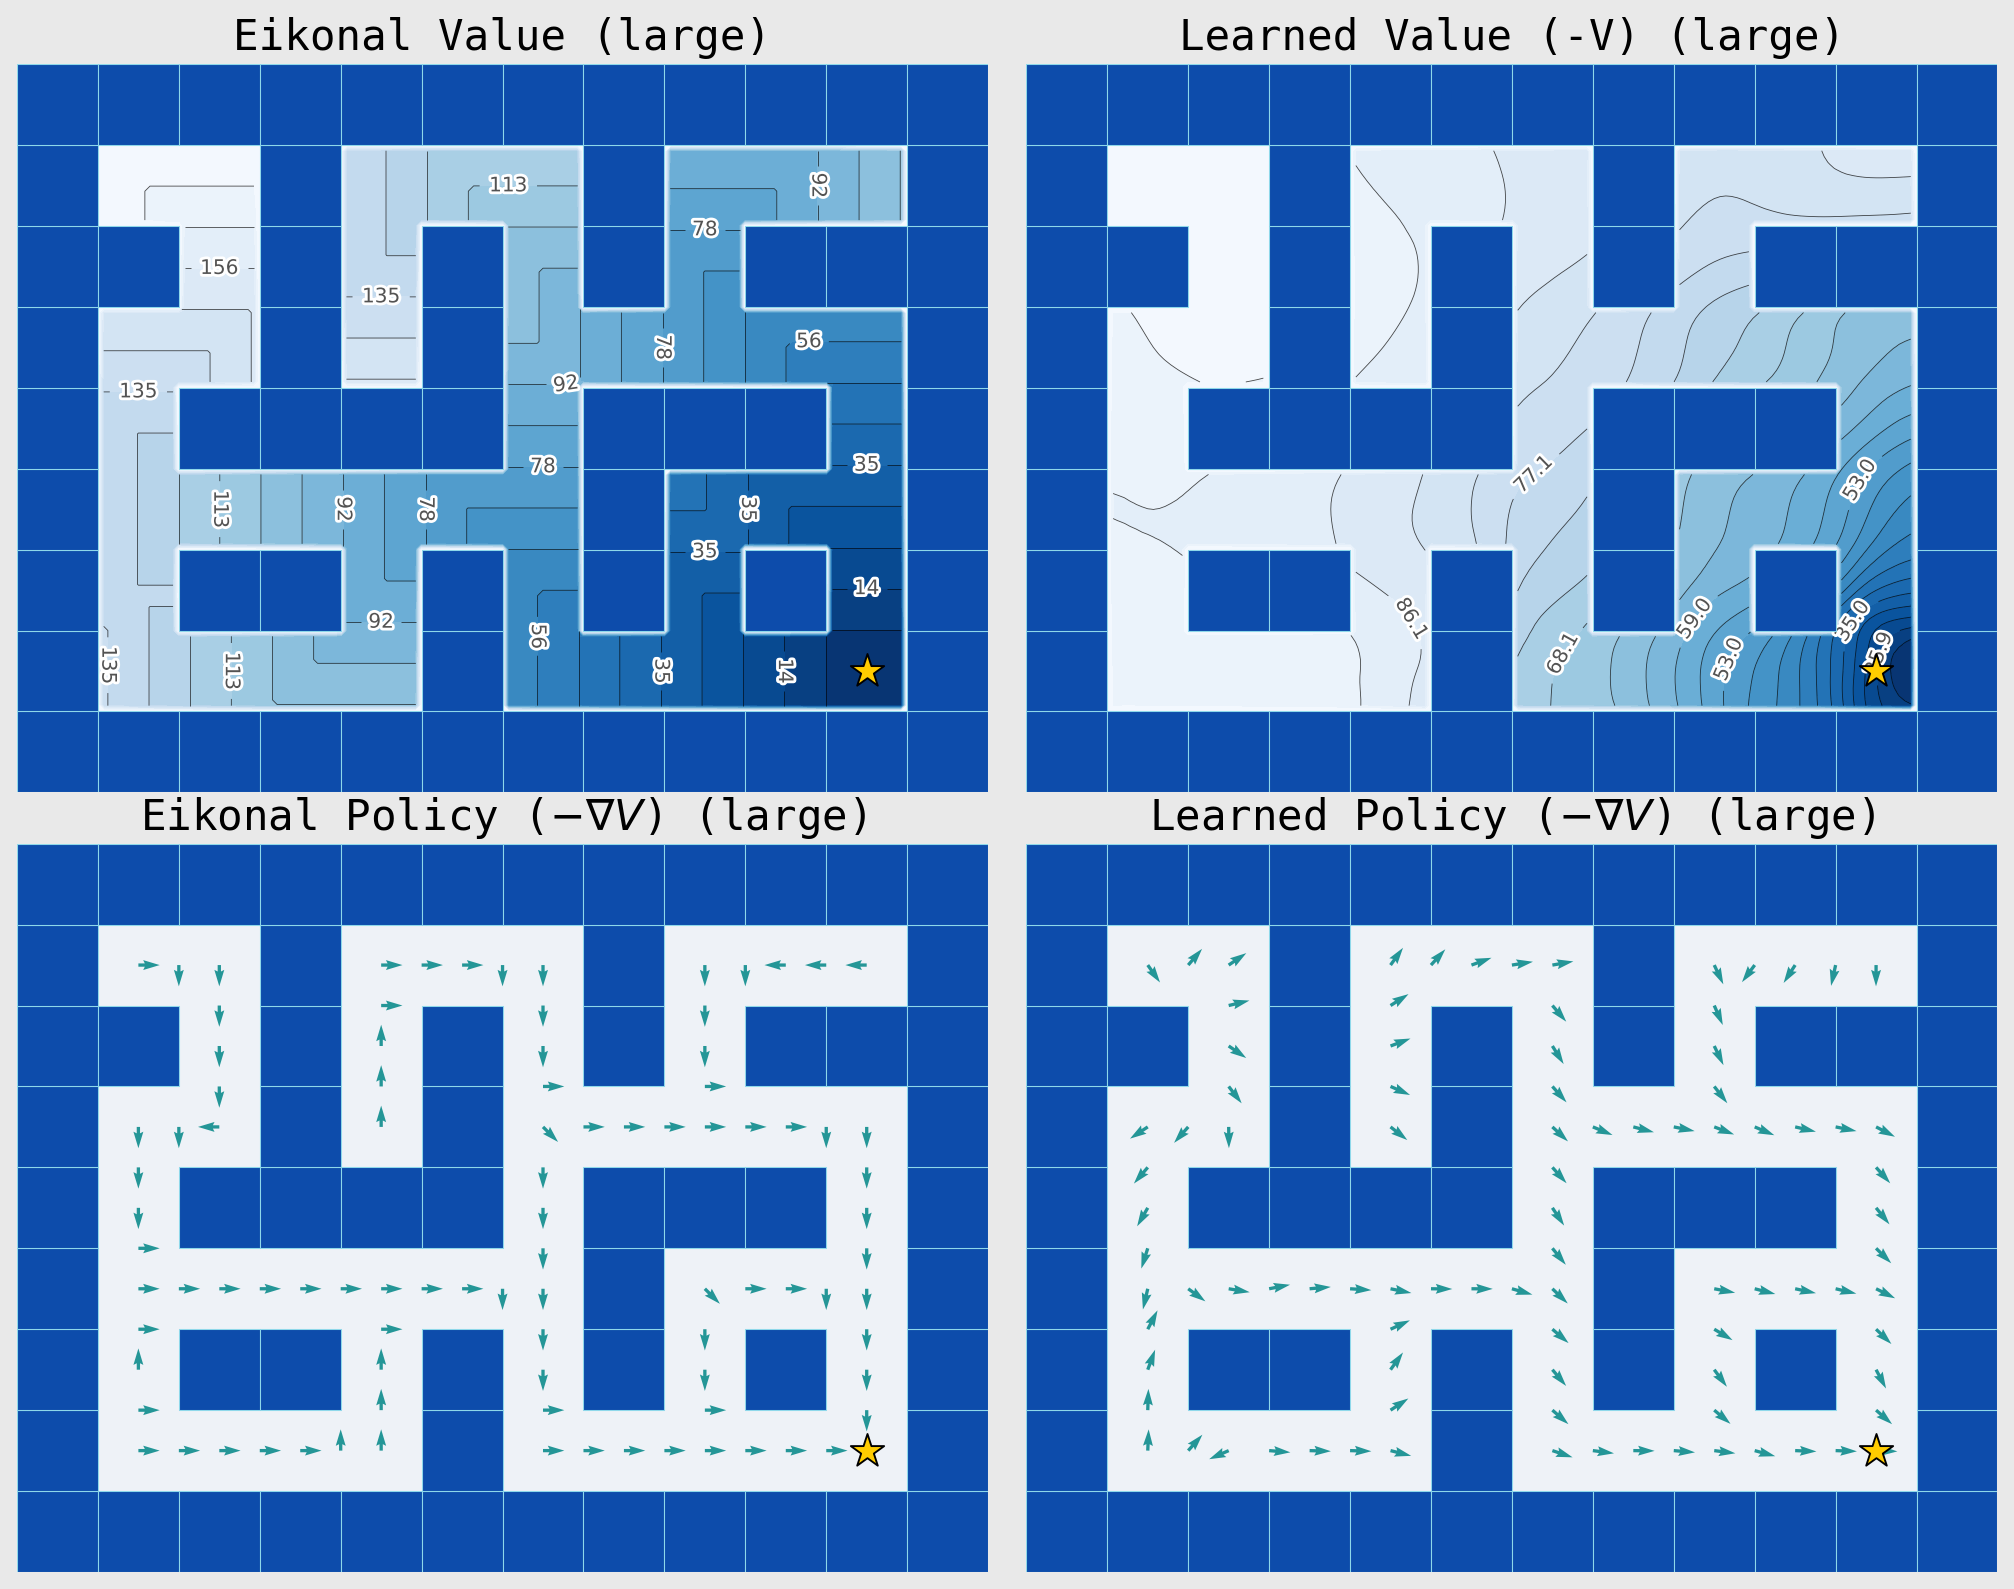

'plots/antmaze_large_learned_analytic_contours.png'

In [8]:
plot_agent_contours(agent_gcivl_dual_eikonal, maze_type='large', env=env_large)

Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/crl/antmaze-large-navigate-v0_crl_sd000_crl-orig-awr/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl/antmaze-large-navigate-v0_gcivl_sd000_eikonal/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/gcivl_dual/antmaze-large-navigate-v0_gcivl_dual_sd000_eikonal-dual/checkpoints
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/mqe/antmaze-large-navigate-v0_mqe_sd000_mqe-original/checkpoints
Loaded runs:
 - crl (crl orig awr)
 - GCIVL
 - GCIVL (eikonal)
 - GCIVL-Dual
 - GCIVL-Dual (eik

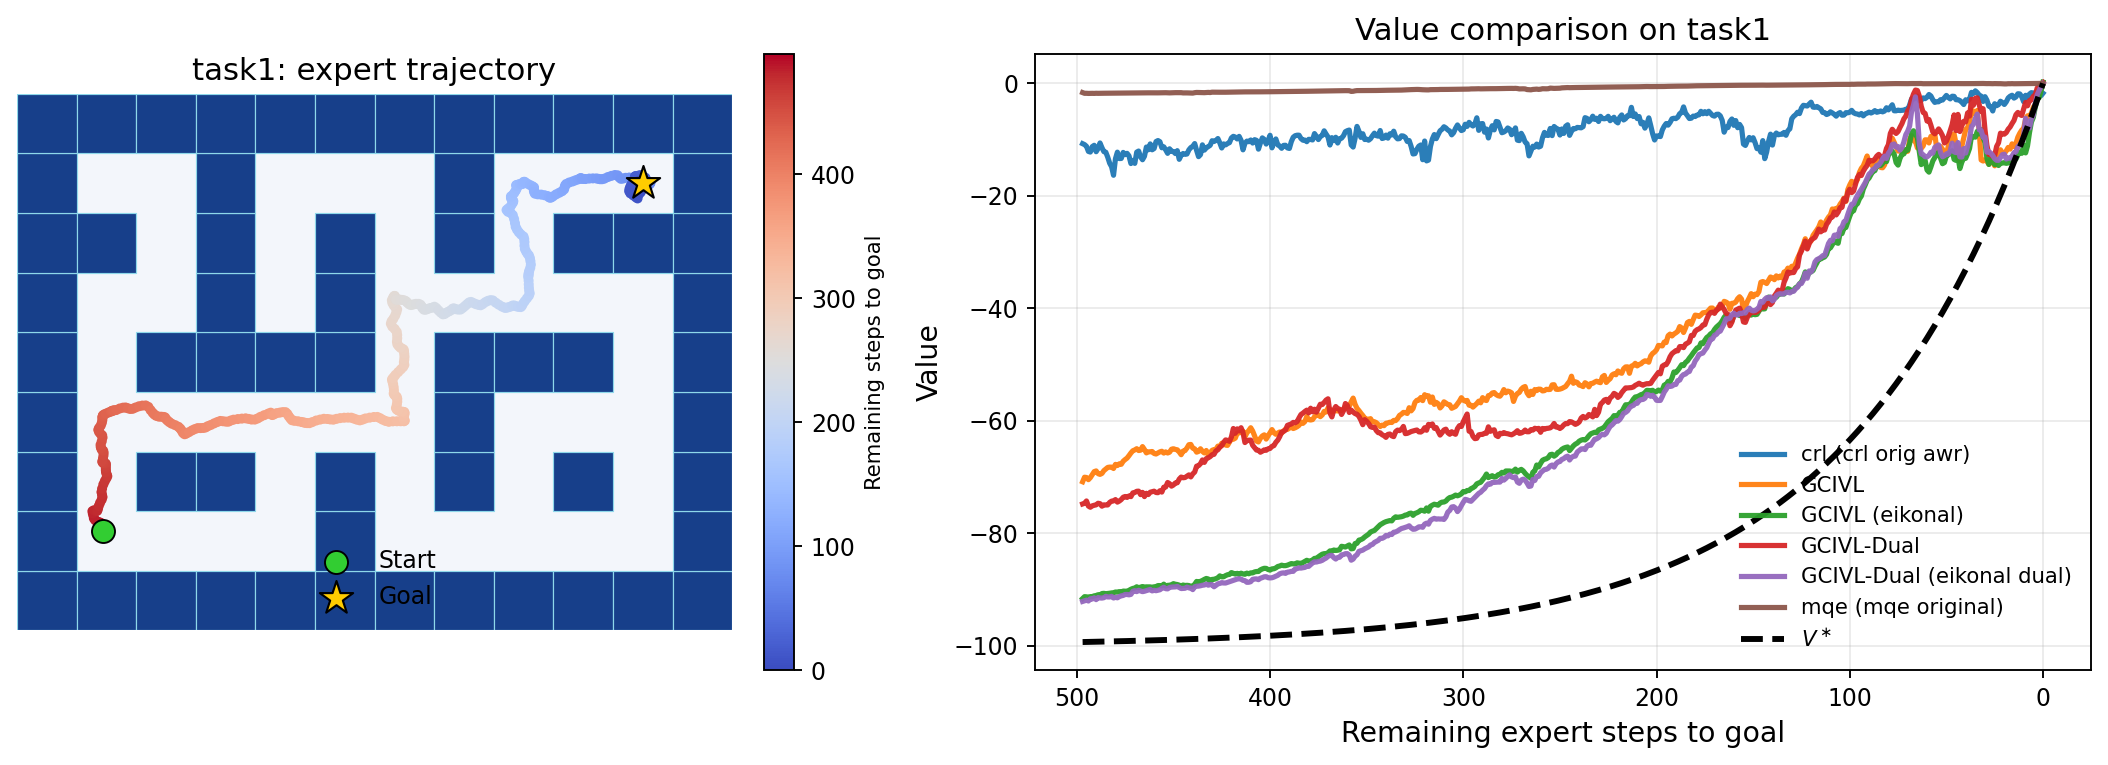

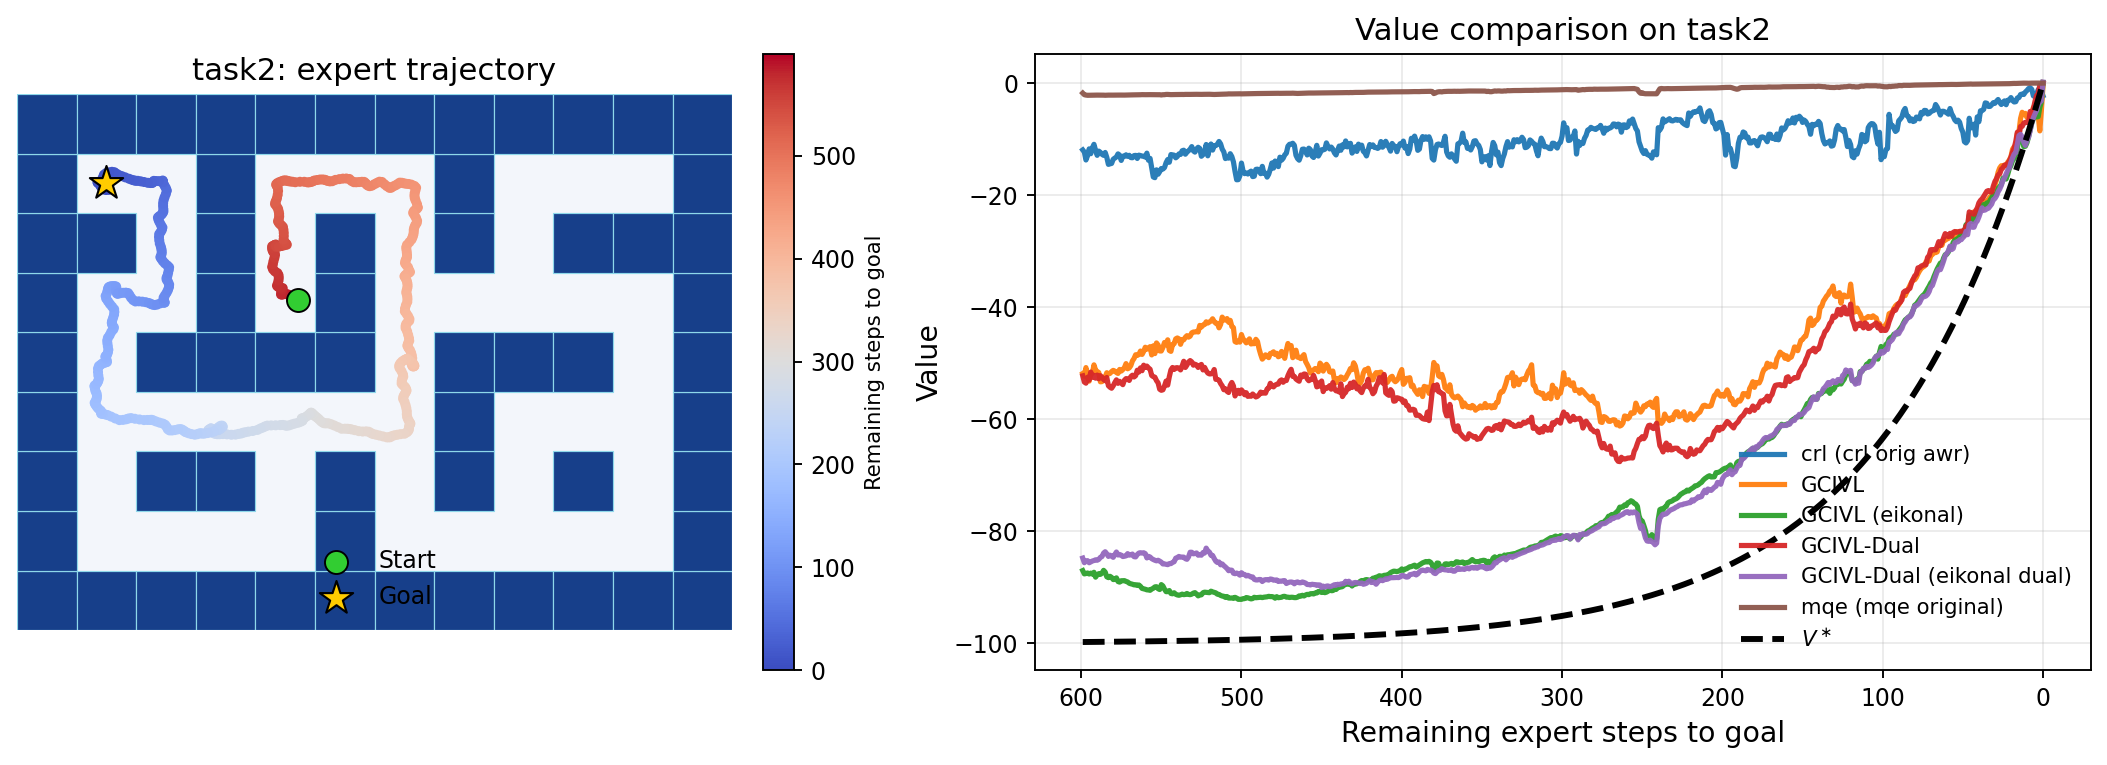

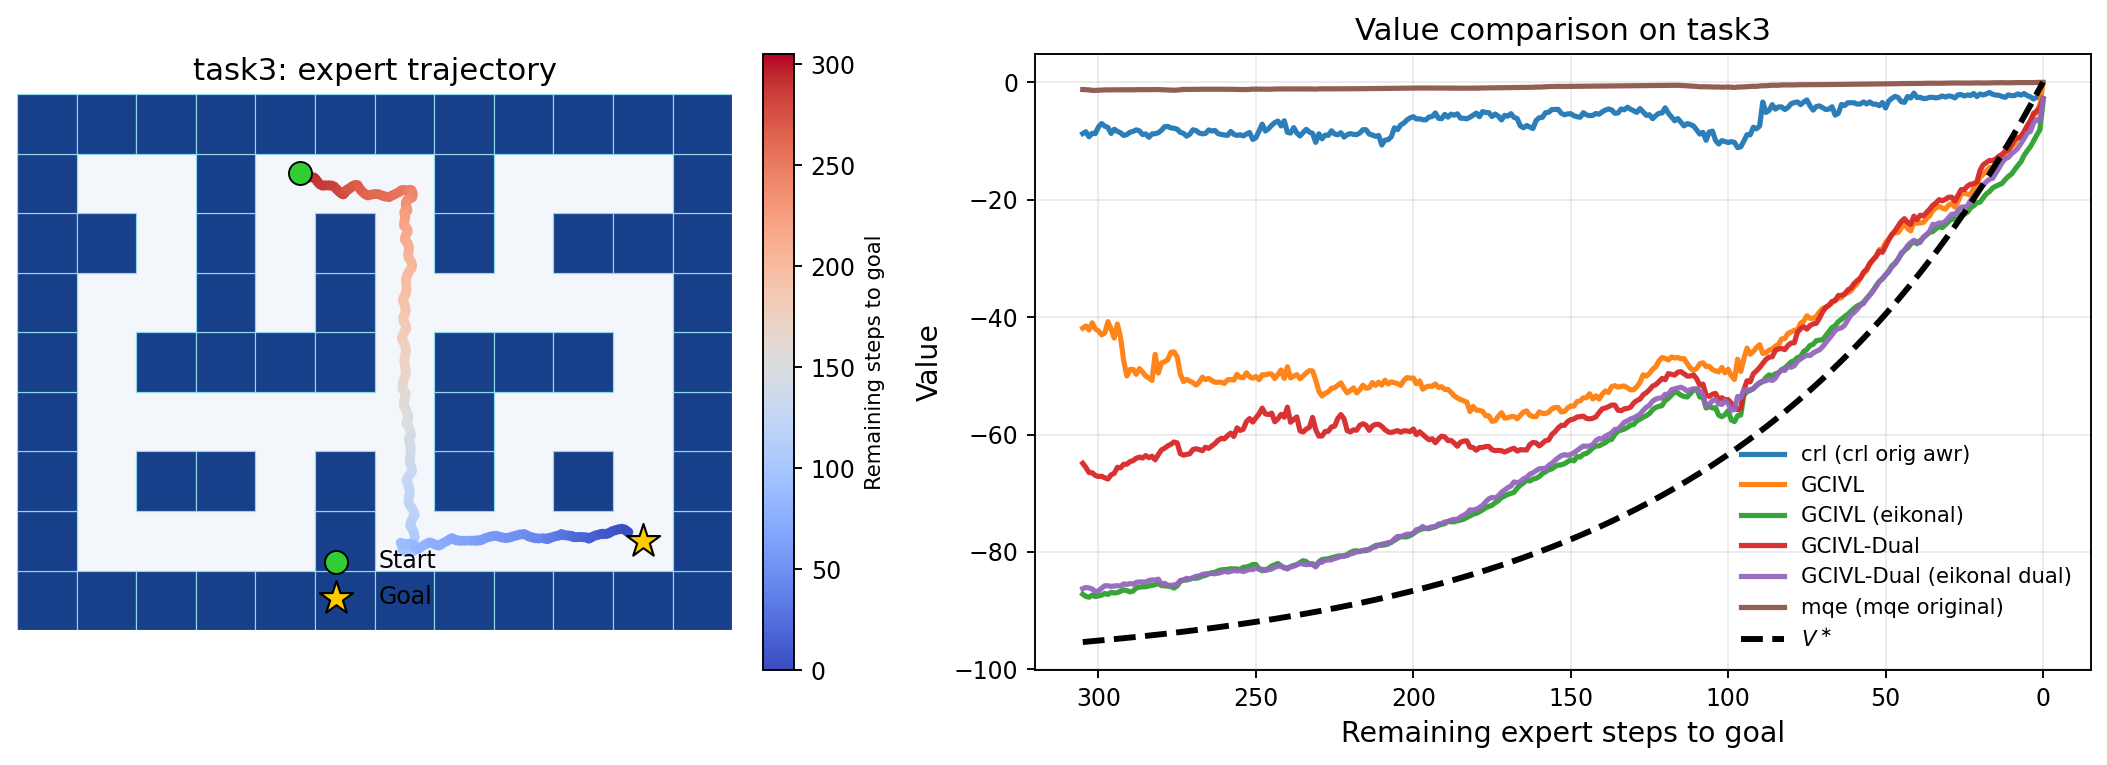

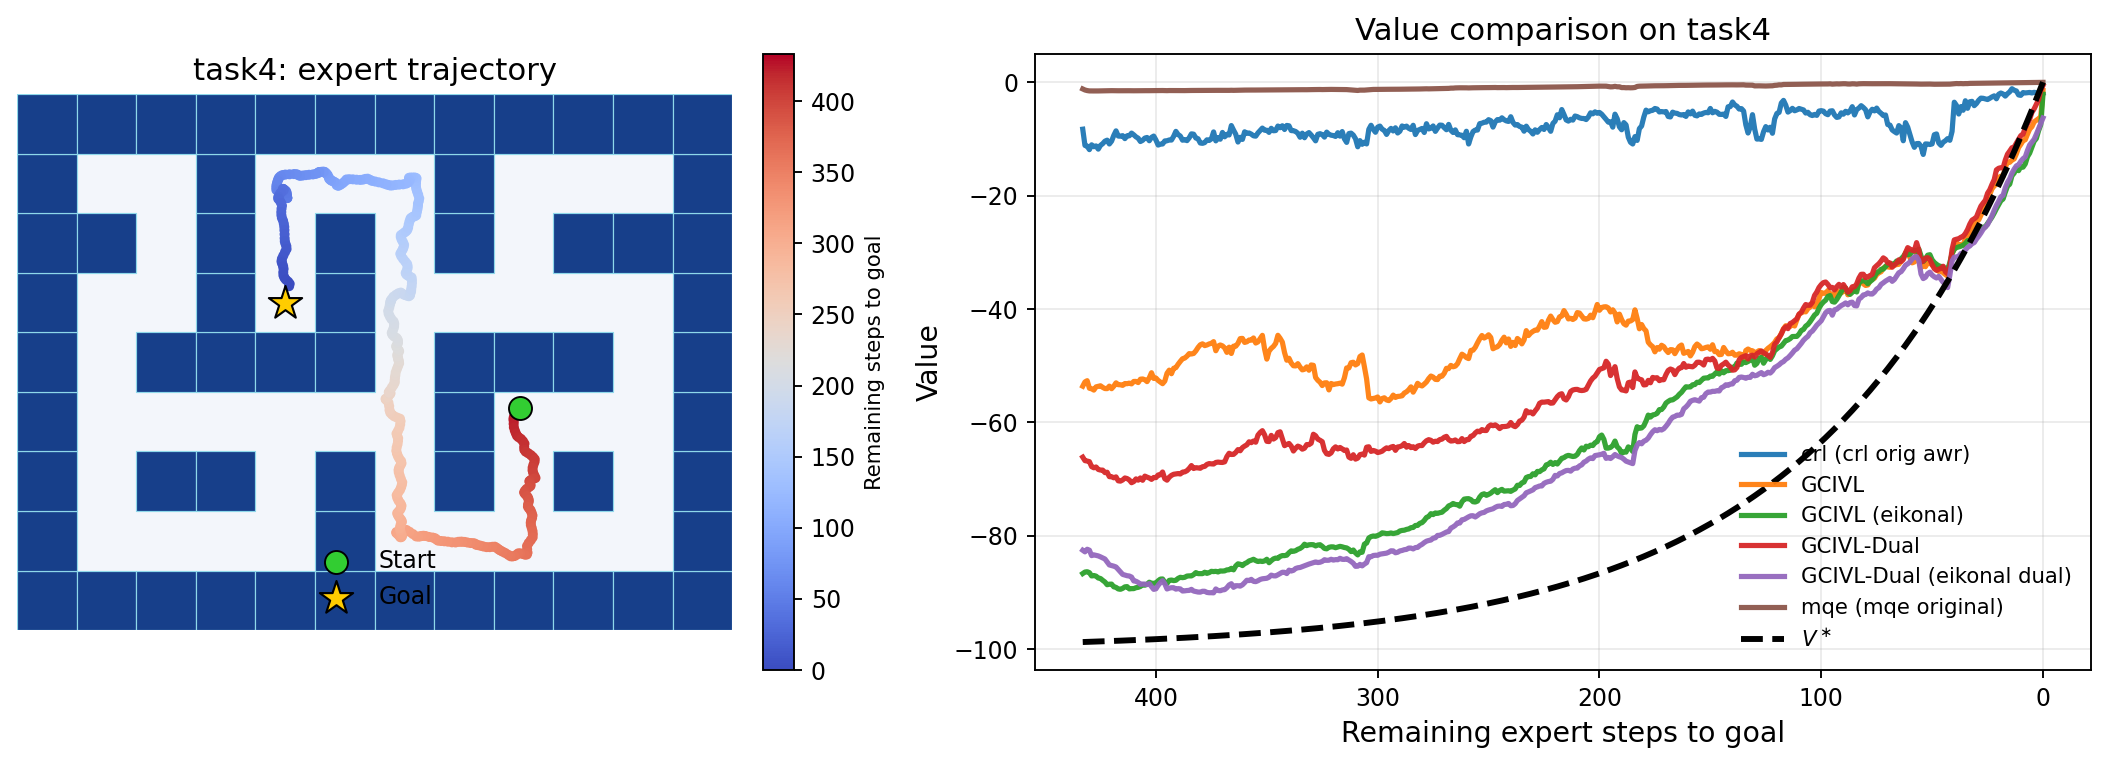

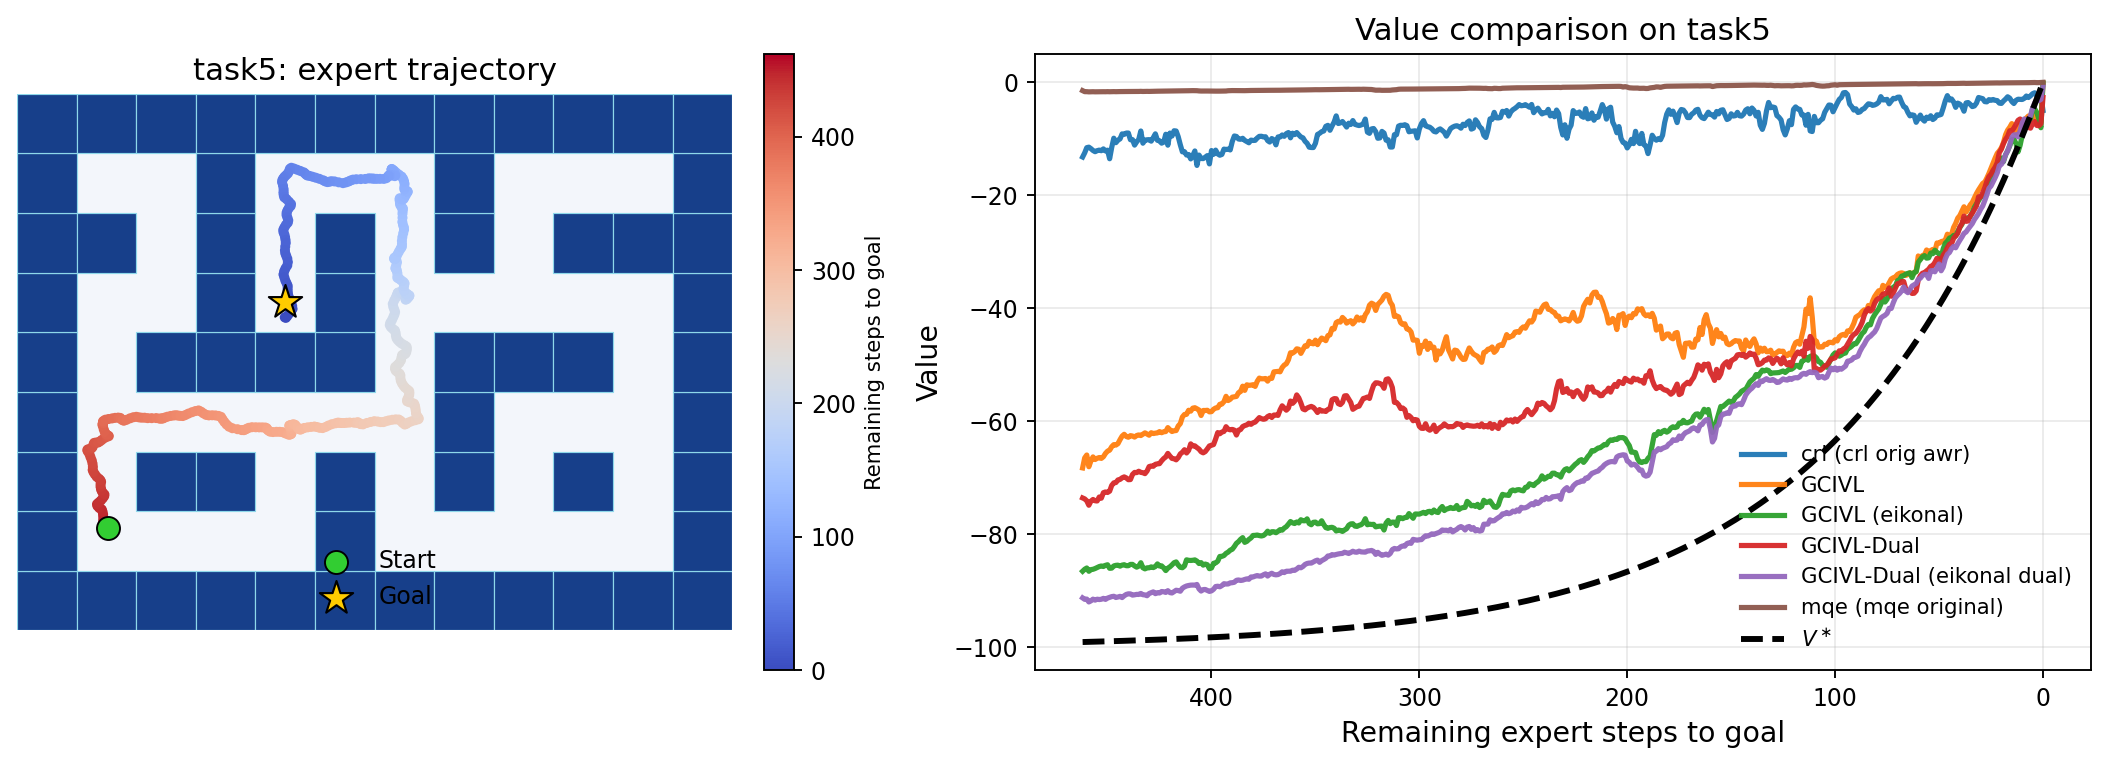

['plots/expert_value_profiles_compare/task1_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task2_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task3_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task4_all_agents_value_profile.png',
 'plots/expert_value_profiles_compare/task5_all_agents_value_profile.png']

In [3]:
import os
import re
import json
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import jax
import jax.numpy as jnp
import ml_collections
import ogbench
from agents import agents as agent_registry
from utils.datasets import Dataset, GCDataset, HGCDataset, VIPDataset
from utils.flax_utils import restore_agent
from scipy.stats import spearmanr
from utils.antmaze_contours import _build_antmaze_grid_and_analytic, _compute_learned_value_grid
%matplotlib inline

def rank_corr(v_learned, v_star):
    """Spearman rank correlation between learned and optimal value profiles."""
    rho, _ = spearmanr(v_learned, v_star)
    return rho


def plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=None,   # None -> latest
):
    os.makedirs(save_dir, exist_ok=True)
    # ------------------------------------------------------------
    # Build env + raw dataset once
    # ------------------------------------------------------------
    env, train_dataset_raw, _ = ogbench.make_env_and_datasets(dataset_name=env_name)
    dataset_class_map = {
        "GCDataset": GCDataset,
        "HGCDataset": HGCDataset,
        "VIPDataset": VIPDataset,
    }
    def make_example_batch(agent_cfg):
        dataset_class = dataset_class_map[agent_cfg["dataset_class"]]
        wrapped_dataset = dataset_class(
            Dataset.create(norm=agent_cfg["norm"], **train_dataset_raw),
            agent_cfg,
        )
        return wrapped_dataset.sample(1)
    # ------------------------------------------------------------
    # Build maze geometry once
    # ------------------------------------------------------------
    (
        X,
        Y,
        x_grid,
        y_grid,
        hx,
        hy,
        obstacle_mask,
        rects,
        v_eik_plot,
        v_fk_plot,
        v_eik_lines,
        v_fk_lines,
        policy_eik_x,
        policy_eik_y,
        policy_fk_x,
        policy_fk_y,
        goal_xy_eval,
        (x_min, x_max, y_min, y_max),
    ) = _build_antmaze_grid_and_analytic(
        maze_type=maze_type,
        points_per_cell=14,
        eikonal_cost_mode="unit",
    )
    # ------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------
    def pretty_label(run_dir_name, agent_name):
        suffix = re.sub(rf"^{re.escape(env_name)}_{re.escape(agent_name)}_sd\d{{3}}_?", "", run_dir_name)
        base = {
            "gcivl": "GCIVL",
            "gcivl_dual": "GCIVL-Dual",
            "hilp": "HILP",
        }.get(agent_name, agent_name)
        if suffix == "":
            return base
        suffix = suffix.replace("_", " + ").replace("-", " ")
        return f"{base} ({suffix})"
    def load_run(run_dir):
        flags_path = os.path.join(run_dir, "flags.json")
        ckpt_dir = os.path.join(run_dir, "checkpoints")
        if not os.path.exists(flags_path) or not os.path.exists(ckpt_dir):
            return None
        with open(flags_path, "r") as f:
            flags_data = json.load(f)
        agent_cfg = flags_data["agent"]
        agent_name = agent_cfg["agent_name"]
        if agent_name not in agent_registry:
            print(f"Skipping {run_dir}: unknown agent '{agent_name}'")
            return None
        example_batch = make_example_batch(agent_cfg)
        agent_cls = agent_registry[agent_name]
        ex_goals = example_batch["value_goals"] if agent_cfg.get("oraclerep", False) else None
        agent = agent_cls.create(
            flags_data["seed"],
            example_batch["observations"],
            example_batch["actions"],
            ml_collections.ConfigDict(agent_cfg),
            ex_goals=ex_goals,
        )
        agent = restore_agent(agent, ckpt_dir, step=checkpoint_step)
        agent = jax.device_put(agent, device=jax.devices("cpu")[0])
        return {
            "label": pretty_label(os.path.basename(run_dir), agent_name),
            "run_dir": run_dir,
            "agent_name": agent_name,
            "discount": float(agent_cfg["discount"]),
            "agent": agent,
            "config": agent_cfg,
        }
    def compute_hilp_value(agent, observations, goal_observations):
        phis = agent.network.select("obs_repr")(observations)
        goal_phis = agent.network.select("obs_repr")(goal_observations)
        # HILP uses ensemble obs_repr with shape (E, B, D)
        if phis.ndim == 3:
            neg_dists = -jnp.sqrt(jnp.maximum(jnp.sum((phis - goal_phis) ** 2, axis=-1), 1e-6))
            agg = agent.config["repr_agg"]
            if agg == "mean":
                values = jnp.mean(neg_dists, axis=0)
            else:
                values = jnp.min(neg_dists, axis=0)
        else:
            values = -jnp.sqrt(jnp.maximum(jnp.sum((phis - goal_phis) ** 2, axis=-1), 1e-6))
        return np.asarray(values, dtype=np.float32)

    def compute_agent_value_profile(agent_bundle, observations, goal_observation):
        agent = agent_bundle["agent"]
        obs = jnp.asarray(observations, dtype=jnp.float32)
        goals = jnp.repeat(
            jnp.asarray(goal_observation[None, :], dtype=jnp.float32),
            repeats=observations.shape[0],
            axis=0,
        )
        modules = agent.network.model_def.modules

        # --- MQE: uses phi/psi modules with quasimetric distance ---
        if "phi" in modules and "psi" in modules:
            psi_s = agent.network.select("psi")(obs)
            psi_g = agent.network.select("psi")(goals)
            # psi may return ensemble shape (E, B, D)
            # if psi_s.ndim == 3:
            #     dists = agent.mrn_distance(psi_s, psi_g)          # (E, B)
            #     values = -(1.0 - jnp.power(0.99, dists)) / (1.0 - 0.99)
            #     # values = -jnp.mean(dists, axis=0)                  # (B,)
            # else:
            dist = agent.mrn_distance(psi_s, psi_g)# * jnp.sqrt(psi_s.shape[-1])
            values = -(1.0 - jnp.power(0.995, dist)) / (1.0 - 0.995)
            return np.asarray(values.mean(0), dtype=np.float32)

        # --- HILP: uses obs_repr ---
        if "obs_repr" in modules:
            return compute_hilp_value(agent, obs, goals)

        # --- CRL / GCIVL / etc.: uses value or rep_value ---
        if "value" in modules or "rep_value" in modules:
            values = _compute_learned_value_grid(agent, obs, goals)
            return np.asarray(values, dtype=np.float32)

        raise ValueError(f"Unsupported value extraction for {agent_bundle['label']}")

        
    def optimal_v_from_remaining_steps(h, gamma):
        h = np.asarray(h, dtype=np.float32)
        if np.isclose(gamma, 1.0):
            return -h
        return -(1.0 - np.power(gamma, h)) / (1.0 - gamma)
    
    def parse_task_idx(path):
        m = re.search(r"task(\d+)\.npz$", os.path.basename(path))
        if m is None:
            return None
        return int(m.group(1)) - 1
    # ------------------------------------------------------------
    # Scan and load runs
    # ------------------------------------------------------------
    run_dirs = sorted(
        {
            str(Path(p).parent)
            for p in glob.glob(os.path.join(results_dir, "*", f"{env_name}_*", "flags.json"))
        }
    )
    loaded_agents = []
    for run_dir in run_dirs:
        try:
            bundle = load_run(run_dir)
            if bundle is not None:
                loaded_agents.append(bundle)
        except Exception as e:
            print(f"Skipping {run_dir}: {e}")
    if not loaded_agents:
        raise ValueError("No compatible runs found in results folder.")
    print("Loaded runs:")
    for bundle in loaded_agents:
        print(f" - {bundle['label']}")
    # ------------------------------------------------------------
    # Collect trajectories
    # ------------------------------------------------------------
    npz_paths = sorted(glob.glob(os.path.join(notebooks_dir, "*.npz")))
    npz_paths = [p for p in npz_paths if parse_task_idx(p) is not None]
    task_infos = env.unwrapped.task_infos
    # Stable colors
    cmap = plt.get_cmap("tab10")
    colors = {bundle["label"]: cmap(i % 10) for i, bundle in enumerate(loaded_agents)}
    saved_paths = []
    for traj_path in npz_paths:
        task_idx = parse_task_idx(traj_path)
        if task_idx is None or task_idx >= len(task_infos):
            continue
        task_info = task_infos[task_idx]
        task_name = task_info["task_name"]
        goal_xy = task_info["goal_xy"]
        traj = np.load(traj_path)
        expert_obs = traj["observations"].astype(np.float32)
        traj_xy = expert_obs[:, :2]
        goal_obs = expert_obs[-1].copy()
        goal_obs[0] = goal_xy[0]
        goal_obs[1] = goal_xy[1]
        T = expert_obs.shape[0]
        h_star = np.arange(T - 1, -1, -1, dtype=np.float32)
        # Use discount from first loaded agent for V*
        # (all current antmaze runs should share gamma=0.99)
        v_star = optimal_v_from_remaining_steps(h_star, loaded_agents[0]["discount"])
        fig, (ax_maze, ax_line) = plt.subplots(
            1,
            2,
            figsize=(12.5, 4.6),
            dpi=170,
            gridspec_kw={"width_ratios": [1.0, 1.35]},
        )
        # Left: same maze/expert trajectory for all approaches
        ax_maze.set_facecolor("#f3f6fb")
        for xmin, ymin, xmax, ymax in rects:
            ax_maze.add_patch(
                plt.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    facecolor="#173f8a",
                    edgecolor="#8ed8ea",
                    linewidth=0.5,
                    zorder=1,
                )
            )
        # ax_maze.plot(traj_xy[:, 0], traj_xy[:, 1], color="#d62728", lw=2.8, zorder=3)
        sc = ax_maze.scatter(
            traj_xy[:, 0],
            traj_xy[:, 1],
            c=h_star,                # color = remaining steps to goal
            cmap="coolwarm",
            s=18,
            zorder=3,
            edgecolors="none",
        )
        cbar = fig.colorbar(sc, ax=ax_maze, fraction=0.046, pad=0.04)
        cbar.set_label("Remaining steps to goal", fontsize=9)
        ax_maze.scatter(
            traj_xy[0, 0],
            traj_xy[0, 1],
            s=95,
            color="#32cd32",
            edgecolor="black",
            linewidth=0.8,
            zorder=4,
            label="Start",
        )
        ax_maze.scatter(
            goal_xy[0],
            goal_xy[1],
            marker="*",
            s=220,
            color="#ffcc00",
            edgecolor="black",
            linewidth=0.9,
            zorder=5,
            label="Goal",
        )
        ax_maze.set_xlim(x_min, x_max)
        ax_maze.set_ylim(y_min, y_max)
        ax_maze.set_aspect("equal")
        ax_maze.set_xticks([])
        ax_maze.set_yticks([])
        for spine in ax_maze.spines.values():
            spine.set_visible(False)
        ax_maze.set_title(f"{task_name}: expert trajectory", fontsize=13)
        ax_maze.legend(frameon=False, fontsize=10, loc="lower center")
        # Right: compare all agents
        for bundle in loaded_agents:
            try:
                v_learned = compute_agent_value_profile(bundle, expert_obs, goal_obs)
                # v_min, v_max = v_learned.min(), v_learned.max()
                # v_normed = (v_learned - v_min) / (v_max - v_min + 1e-8)
                # rho = rank_corr(v_normed, v_star)
                ax_line.plot(
                    h_star,
                    v_learned, # v_normed
                    lw=2.2,
                    color=colors[bundle["label"]],
                    label=f"{bundle['label']}", # (ρ={rho:.3f})",
                    alpha=0.95,
                )
            except Exception as e:
                print(f"Could not plot {bundle['label']} on {task_name}: {e}")
        # vs_min, vs_max = v_star.min(), v_star.max()
        # v_star_normed = (v_star - vs_min) / (vs_max - vs_min + 1e-8)
        ax_line.plot(h_star, v_star, "k--", lw=2.5, label=r"$V^\ast$")
        ax_line.set_xlabel("Remaining expert steps to goal", fontsize=12)
        ax_line.set_ylabel("Value", fontsize=12)
        ax_line.set_title(f"Value comparison on {task_name}", fontsize=13)
        ax_line.invert_xaxis()
        ax_line.grid(alpha=0.25)
        ax_line.legend(frameon=False, fontsize=9, loc="best")
        plt.tight_layout()
        save_path = os.path.join(save_dir, f"{task_name}_all_agents_value_profile.png")
        fig.savefig(save_path, bbox_inches="tight")
        saved_paths.append(save_path)
        if show_inline:
            display(fig)
        plt.close(fig)
    return {
        "loaded_agents": loaded_agents,
        "saved_paths": saved_paths,
    }
comparison = plot_all_found_agents_on_expert_trajectories(
    results_dir="../results",
    notebooks_dir="../notebooks",
    env_name="antmaze-large-navigate-v0",
    maze_type="large",
    save_dir="plots/expert_value_profiles_compare",
    show_inline=True,
    checkpoint_step=1_000_000,   # or None for latest
)
comparison["saved_paths"]